In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1 - READ AND OVERVIEW DATA

In [35]:
df = pd.read_csv(r'D:\Project\house_price_prediction\data\train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [36]:
df.shape

(1460, 81)

In [37]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [39]:
df = df.drop('Id', axis=1)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# STEP 2 - Understand TARGET VARIABLE

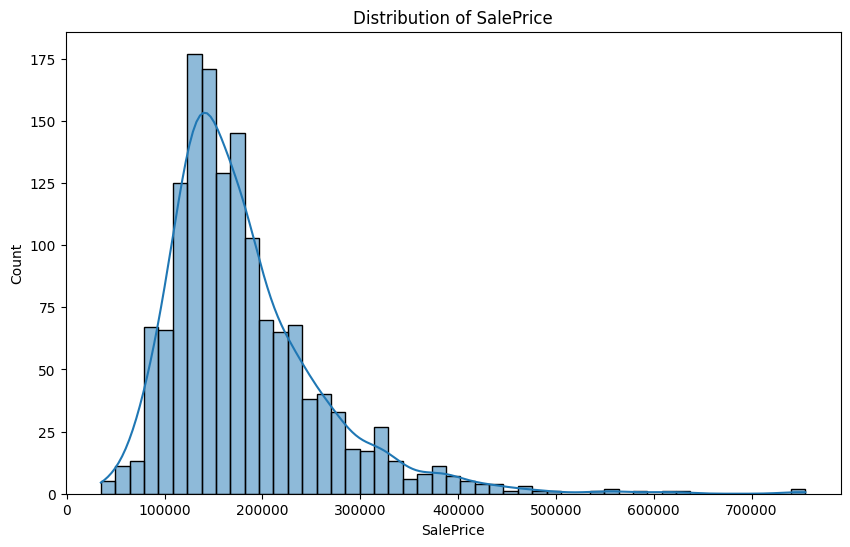

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

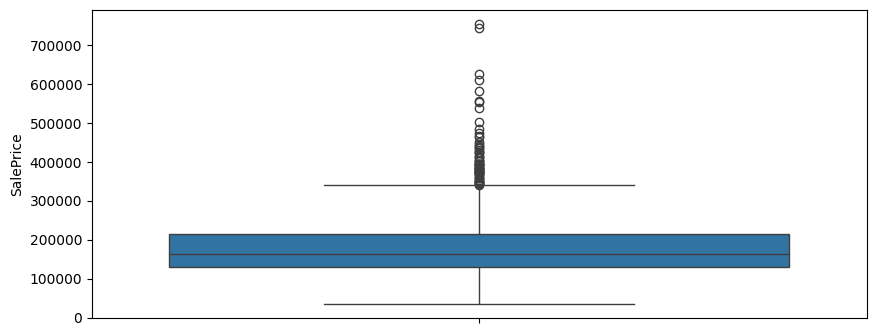

In [41]:
plt.figure(figsize=(10,4))
sns.boxplot(y=df['SalePrice'])
plt.show()

In [42]:
df['SalePrice'].mean()

np.float64(180921.19589041095)

In [43]:
df['SalePrice'].median()

np.float64(163000.0)

# STEP 3 -  Missing Values Analysis

In [44]:
missing_value = df.isnull().sum().sort_values(ascending=False)

In [45]:
missing_value.head()

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64

In [46]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.head()

MSSubClass      0.000000
MSZoning        0.000000
LotFrontage    17.739726
LotArea         0.000000
Street          0.000000
dtype: float64

In [47]:
missing_data = pd.DataFrame({
    'Missing Values': missing_value,
    'Percentage': missing_percent
})

In [48]:
missing_data = missing_data.sort_values(by='Percentage', ascending=False)

In [49]:
missing_data.head(20)

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageFinish,81,5.547945
GarageYrBlt,81,5.547945
GarageCond,81,5.547945


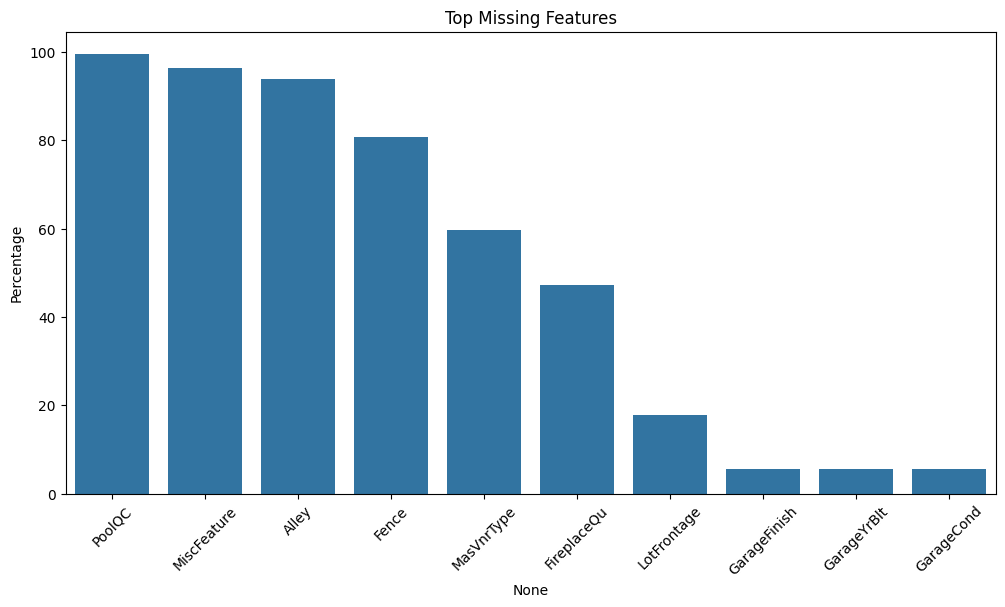

In [50]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=missing_data.head(10).index,
    y=missing_data.head(10)['Percentage']
)
plt.xticks(rotation=45)
plt.title('Top Missing Features')
plt.show()

In [51]:
none_cols = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'MasVnrType'
]

In [52]:
for col in none_cols:
    df[col] = df[col].fillna('None')

In [53]:
for col in none_cols:
    df[col] = df[col].fillna('None')

In [54]:
median_cols = [
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt'
]

In [55]:
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

In [56]:
mode_cols = [
    'Electrical',
    'MSZoning',
    'KitchenQual',
    'Exterior1st',
    'Exterior2nd',
    'SaleType'
]

In [57]:
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [58]:
df.isnull().sum().sort_values(ascending=False).head(20)

MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
Alley           0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
dtype: int64

In [59]:
df.drop(columns=['Utilities'], inplace=True)

# STEP 4 — Numerical Features Analysis

### STEP 4.1 - Lấy numerical columns

In [60]:
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

### STEP 4.2 — Correlation Matrix

In [61]:
corr_matrix = df[numerical_cols].corr()

### STEP 4.3 — Correlation với SalePrice

In [62]:
saleprice_corr = corr_matrix['SalePrice'].sort_values(
    ascending=False
)

In [63]:
saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

### STEP 4.4 — Visualize relationship

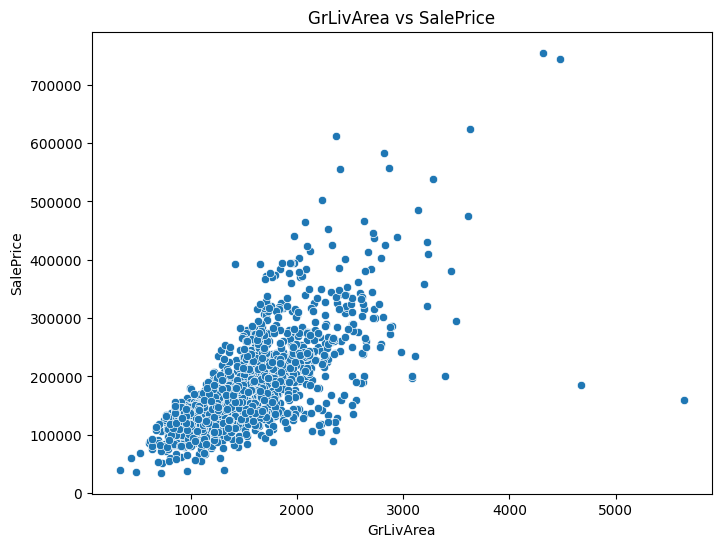

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice']
)
plt.title('GrLivArea vs SalePrice')
plt.show()

### STEP 4.5 — Analyze thêm vài feature mạnh

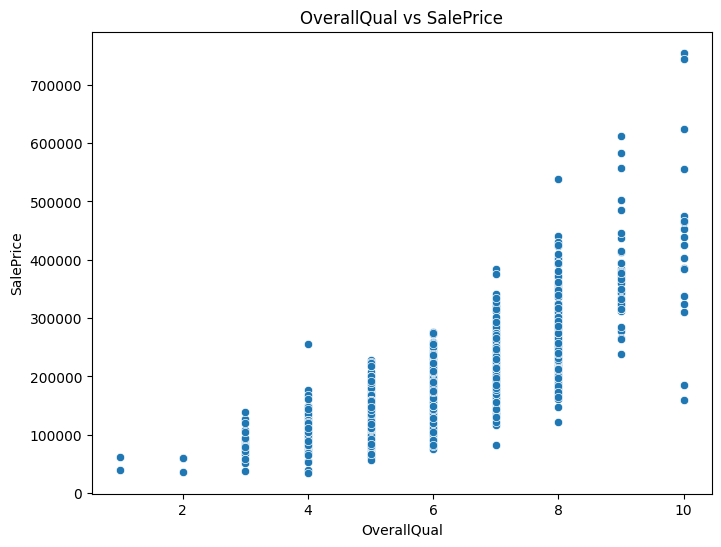

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['OverallQual'],
    y=df['SalePrice']
)
plt.title('OverallQual vs SalePrice')
plt.show()

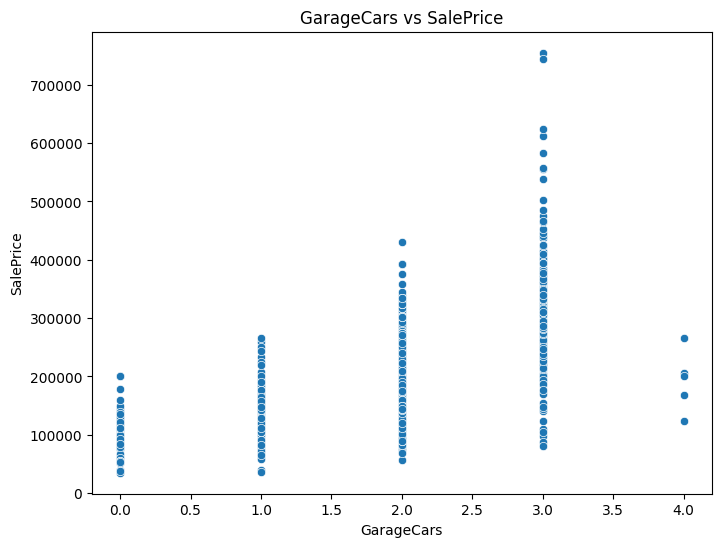

In [68]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GarageCars'],
    y=df['SalePrice']
)
plt.title('GarageCars vs SalePrice')
plt.show()

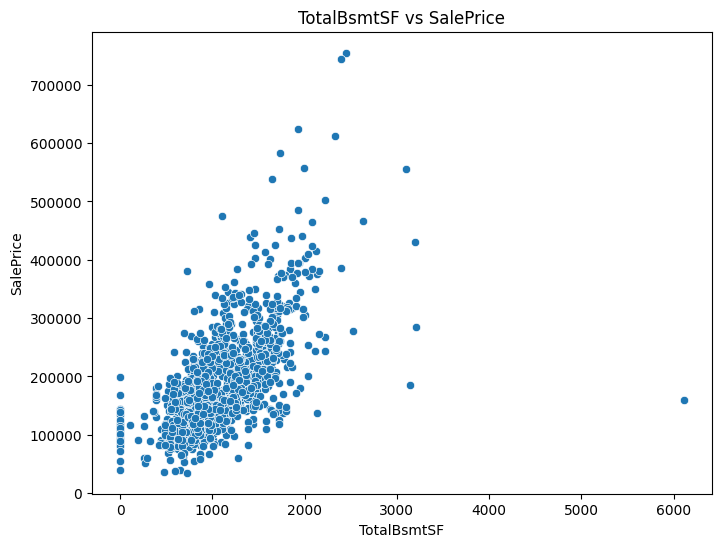

In [69]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['TotalBsmtSF'],
    y=df['SalePrice']
)
plt.title('TotalBsmtSF vs SalePrice')
plt.show()

### STEP 4.6 — Heatmap

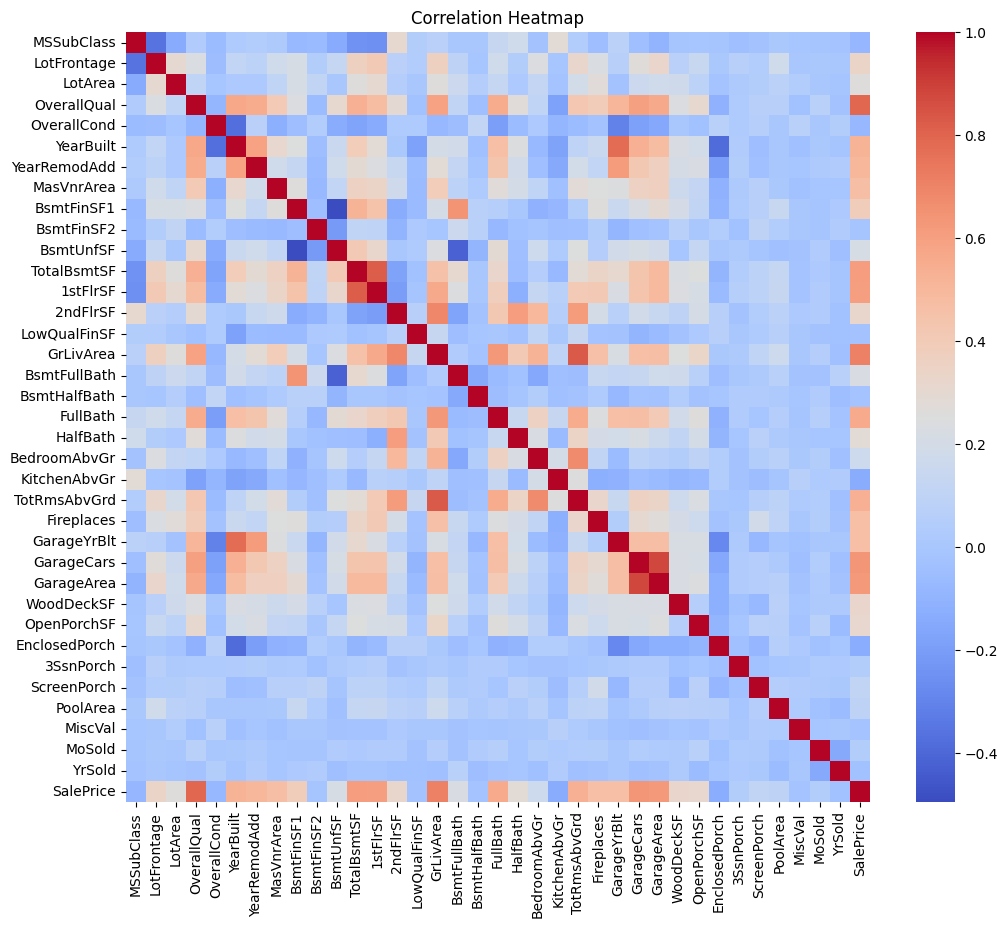

In [70]:
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# STEP 5 - Categorical Features Analysis
- Neighborhood
- HouseStyle
- ExterQual
- KitchenQual
- GarageType

### STEP 5.1 — Tính giá trung bình theo khu vực

In [72]:
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

In [73]:
neighborhood_price

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

### STEP 5.2 — Visualize bằng barplot

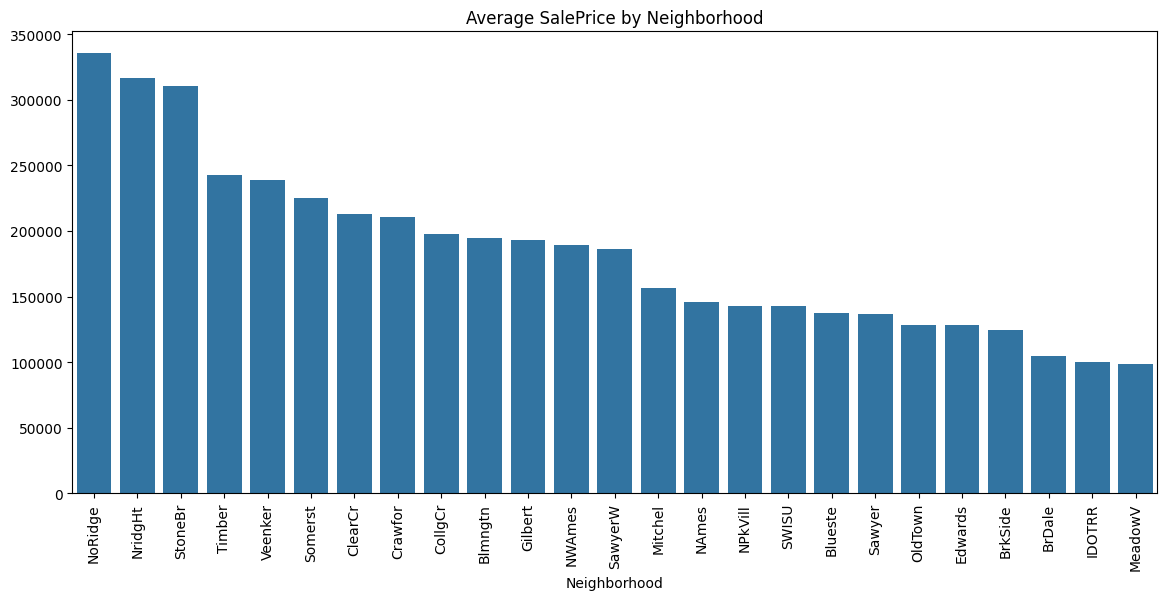

In [74]:
plt.figure(figsize=(14,6))
sns.barplot(
    x=neighborhood_price.index,
    y=neighborhood_price.values
)
plt.xticks(rotation=90)
plt.title('Average SalePrice by Neighborhood')
plt.show()

### STEP 5.3 — Boxplot

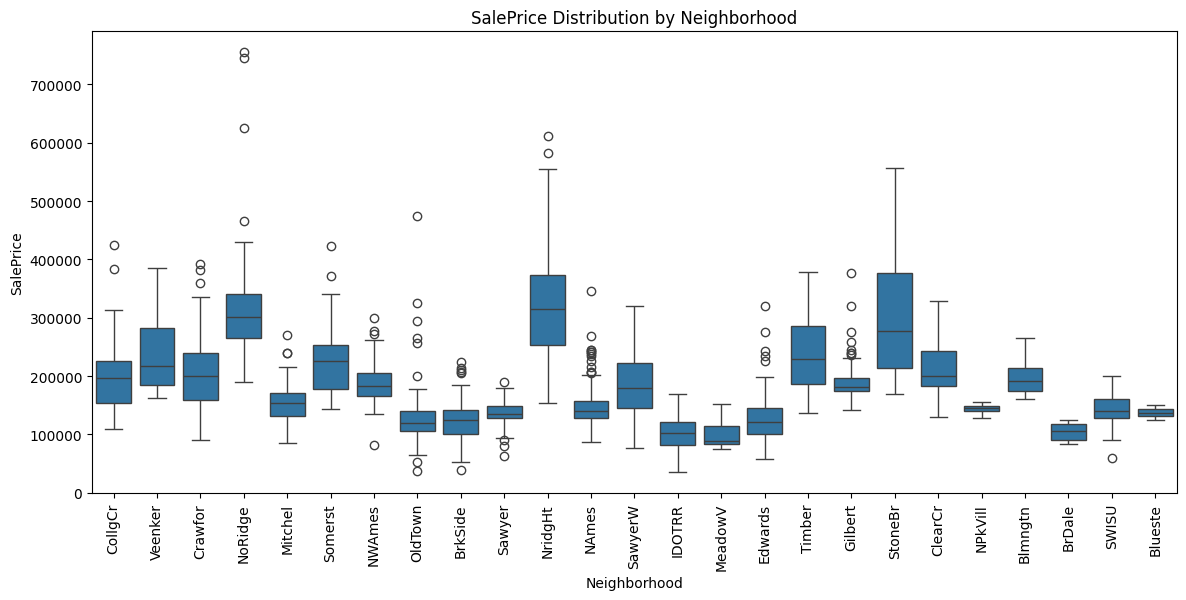

In [75]:
plt.figure(figsize=(14,6))
sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=df
)
plt.xticks(rotation=90)
plt.title('SalePrice Distribution by Neighborhood')
plt.show()

# STEP 6 — Correlation Analysis

### STEP 6.1 — Tạo correlation matrix

In [76]:
corr_matrix = df.select_dtypes(
    include=['int64', 'float64']
).corr()

### STEP 6.2 — Heatmap

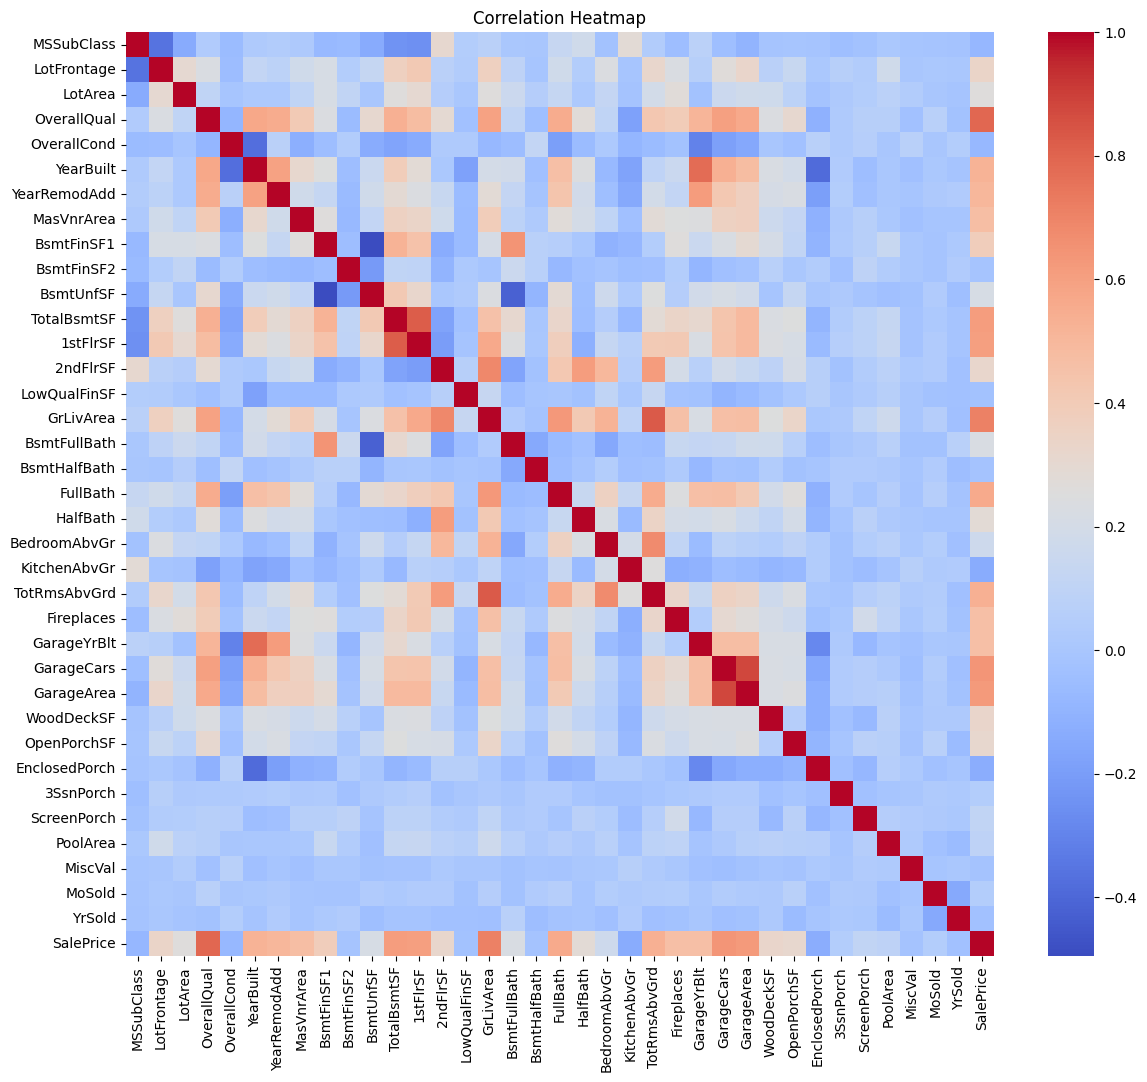

In [77]:
plt.figure(figsize=(14,12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

### STEP 6.3 — Correlation với SalePrice

In [78]:
saleprice_corr = corr_matrix['SalePrice'].sort_values(
    ascending=False
)

In [79]:
saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [80]:
saleprice_corr.tail(10)

3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

# STEP 7 — Outlier Handling

### STEP 7.1 — Visualize outlier rõ hơn

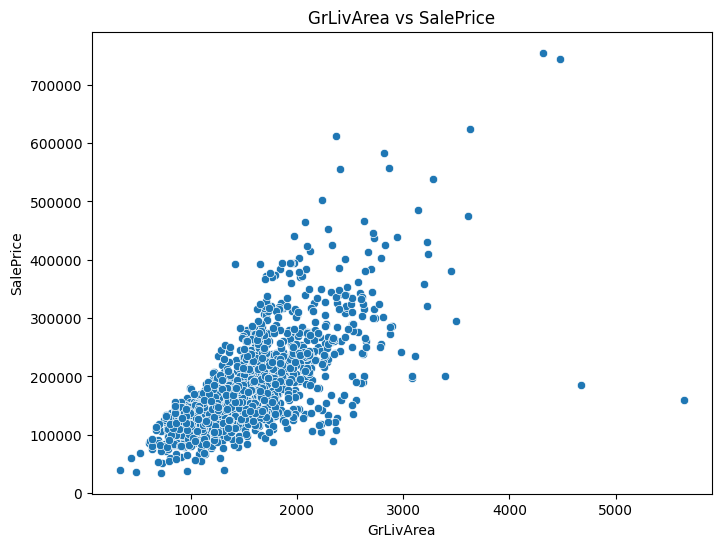

In [81]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice']
)
plt.title('GrLivArea vs SalePrice')
plt.show()

### STEP 7.2 — Xác định outlier condition

### STEP 7.3 — Xem outlier

In [82]:
outliers = df[
    (df['GrLivArea'] > 4000) &
    (df['SalePrice'] < 300000)
]
outliers

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,60,RL,130.0,40094,Pave,None,IR1,Bnk,Inside,Gtl,...,0,None,None,None,0,10,2007,New,Partial,184750
1298,60,RL,313.0,63887,Pave,None,IR3,Bnk,Corner,Gtl,...,480,Gd,None,None,0,1,2008,New,Partial,160000


### STEP 7.4 — Remove outlier

In [83]:
df = df.drop(outliers.index)

### STEP 7.5 — Recheck distribution

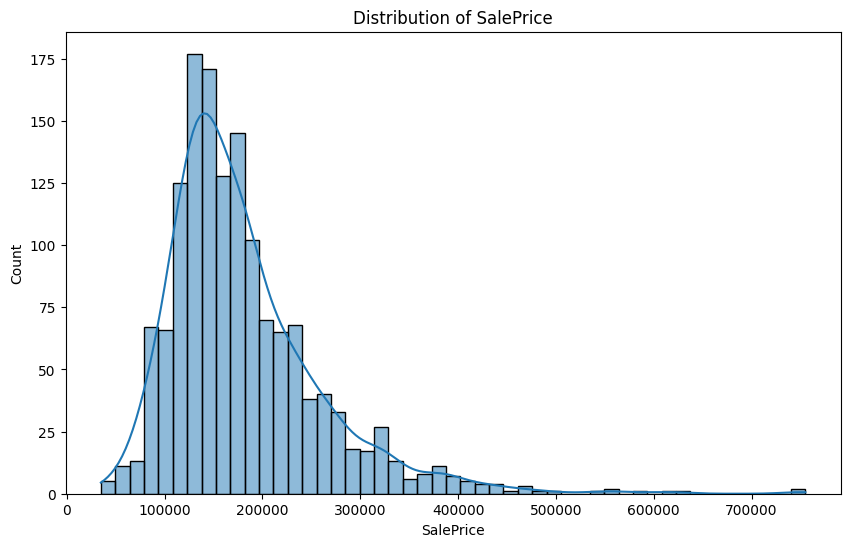

In [84]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()